**Objective:** model and interpret the drivers of country-level mobile money adoption rates (`mobileaccount_t_d`).

In [2]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling & stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Diagnostics
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Quick plotting style
sns.set_theme(style="whitegrid")


In [3]:
# Load data
df = pd.read_csv('../data/processed/global_findex_cleaned.csv')
df.head()

,countrynewwb,codewb,year,pop_adult,regionwb24_hi,incomegroupwb24,group,group2,account_t_d,fiaccount_t_d,...,con18,con19,internet,con26d,con27,con30a,con30b,con30c,con30d,con30e
0,Afghanistan,AFG,2011,14575546.0,South Asia (excluding high income),Low income,all,all,0.090050,0.090050,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,ALB,2011,2281010.0,Europe & Central Asia (excluding high income),Upper middle income,all,all,0.282681,0.282681,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Algeria,DZA,2011,26251587.0,Middle East & North Africa (excluding high inc...,Lower middle income,all,all,0.332861,0.332861,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Angola,AGO,2011,12779501.0,Sub-Saharan Africa (excluding high income),Lower middle income,all,all,0.392035,0.392035,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Argentina,ARG,2011,30685516.0,Latin America & Caribbean (excluding high income),Upper middle income,all,all,0.331302,0.331302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Quick check (shape / columns / dtypes / missing)
print("shape:", df.shape)
print("\nColumns (sample):", df.columns.tolist()[:40])
print("\nMissing per columns (top 20):")
print(df.isnull().sum().sort_values(ascending=False).head(20))
df.describe(include='all').T

shape: (7880, 126)

Columns (sample): ['countrynewwb', 'codewb', 'year', 'pop_adult', 'regionwb24_hi', 'incomegroupwb24', 'group', 'group2', 'account_t_d', 'fiaccount_t_d', 'mobileaccount_t_d', 'borrow_any_t_d', 'fin4_d', 'dig_acc', 'fin26a', 'fin26b', 'fin27a', 'fin17a_17a1_d', 'fin17a', 'fin17b', 'fin17c', 'fin22d', 'fin22e', 'fin22a_22a1_22g_d', 'fin22a', 'fin22b', 'fin22c', 'fin24sav', 'fin24fam', 'fin24work', 'fin24bor', 'fin24sell', 'fin24aVD', 'fin24aSD', 'fin24aND', 'fin24aSD_ND', 'fin24aP', 'fin24aN', 'fin24sav_SD_ND', 'fin24fam_SD_ND']

Missing per columns (top 20):
fin24bor    7078
fh2a        7073
fin6m       7049
fin45e      7029
fin9b       7013
con26d      7004
con30e      6992
fin5m       6989
fin22h      6983
fin9a       6977
fin22c      6976
fin17b      6976
con30d      6956
con30a      6956
con30b      6956
fin8        6953
con27       6932
fin34b      6932
con30c      6920
con11       6908
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
countrynewwb,7880,162,Malawi,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
codewb,7880,162,MWI,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,7880.0,NaN,NaN,NaN,2017.762563,4.700454,2011.0,2014.0,2017.0,2022.0,2024.0
pop_adult,7880.0,NaN,NaN,NaN,38015962.817893,126950906.086927,228016.0,3739546.0,8517166.0,25903954.0,1176678702.0
regionwb24_hi,7880,7,High income,2630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
con30a,924.0,NaN,NaN,NaN,0.478057,0.208324,0.043145,0.311948,0.476158,0.634895,0.976289
con30b,924.0,NaN,NaN,NaN,0.455369,0.196877,0.05776,0.297876,0.449223,0.589511,0.966377
con30c,960.0,NaN,NaN,NaN,0.518547,0.230421,0.047502,0.330125,0.548915,0.705397,0.984643
con30d,924.0,NaN,NaN,NaN,0.44119,0.205357,0.042529,0.270446,0.438448,0.598149,0.942952


# Choose target & candidate predictors.
**Target (y):** `mobileaccount_t_d` (proportion 0-1)
**Candidate predictors (x):**
- `account_t_d`
- `year`
- `regionwb24_hi` (region)
- `incomegroupwb24` (income group)
- `pop_adult`
- `internet`


In [5]:
# Select relevant columns
cols = ['year', 'regionwb24_hi', 'incomegroupwb24', 'pop_adult',
        'account_t_d', 'mobileaccount_t_d', 'internet']
df_model = df[cols].copy()
print("shape:", df_model.shape)
df_model.head()

shape: (7880, 7)


,year,regionwb24_hi,incomegroupwb24,pop_adult,account_t_d,mobileaccount_t_d,internet
0,2011,South Asia (excluding high income),Low income,14575546.0,0.090050,NaN,NaN
1,2011,Europe & Central Asia (excluding high income),Upper middle income,2281010.0,0.282681,NaN,NaN
2,2011,Middle East & North Africa (excluding high inc...,Lower middle income,26251587.0,0.332861,NaN,NaN
3,2011,Sub-Saharan Africa (excluding high income),Lower middle income,12779501.0,0.392035,NaN,NaN
4,2011,Latin America & Caribbean (excluding high income),Upper middle income,30685516.0,0.331302,NaN,NaN


In [6]:
# Handle missing data

# Show how many rows have missing target
print("Rows with missing target:", df_model['mobileaccount_t_d'].isnull().sum())

# Inspect missing pattern for predictors
print("\nMissing per columns:")
print(df_model.isnull().sum().sort_values(ascending=False))

Rows with missing target: 5654

Missing per columns:
internet             6067
mobileaccount_t_d    5654
account_t_d            90
year                    0
regionwb24_hi           0
incomegroupwb24         0
pop_adult               0
dtype: int64


In [7]:
# Impute missing values in the target variable
df_model['mobileaccount_t_d'] = df_model['mobileaccount_t_d'].bfill(axis=0).fillna(0)

# Impute missing values in predictors
df_model['internet'] = df_model['internet'].bfill(axis=0).fillna(0)
df_model['account_t_d'] = df_model['account_t_d'].fillna(df_model['account_t_d'].median())

# Confirm no missing values remain
print("\nMissing per columns after imputation:")
print(df_model.isnull().sum().sort_values(ascending=False))


Missing per columns after imputation:
year                 0
regionwb24_hi        0
incomegroupwb24      0
pop_adult            0
account_t_d          0
mobileaccount_t_d    0
internet             0
dtype: int64


In [8]:

# Encode categorical variables

# Check data types
print(df_model.dtypes)

# One-hot encode categorical variables
categorical_cols = ['regionwb24_hi', 'incomegroupwb24']
df_model_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print("\nShape before encoding:", df_model.shape)
print("\nShape after encoding:", df_model_encoded.shape)
df_model_encoded.head()

year                   int64
regionwb24_hi         object
incomegroupwb24       object
pop_adult            float64
account_t_d          float64
mobileaccount_t_d    float64
internet             float64
dtype: object

Shape before encoding: (7880, 7)

Shape after encoding: (7880, 14)


,year,pop_adult,account_t_d,mobileaccount_t_d,internet,regionwb24_hi_Europe & Central Asia (excluding high income),regionwb24_hi_High income,regionwb24_hi_Latin America & Caribbean (excluding high income),regionwb24_hi_Middle East & North Africa (excluding high income),regionwb24_hi_South Asia (excluding high income),regionwb24_hi_Sub-Saharan Africa (excluding high income),incomegroupwb24_Low income,incomegroupwb24_Lower middle income,incomegroupwb24_Upper middle income
0,2011,14575546.0,0.090050,0.003044,0.828402,False,False,False,False,True,False,True,False,False
1,2011,2281010.0,0.282681,0.003044,0.828402,True,False,False,False,False,False,False,False,True
2,2011,26251587.0,0.332861,0.003044,0.828402,False,False,False,True,False,False,False,True,False
3,2011,12779501.0,0.392035,0.003044,0.828402,False,False,False,False,False,True,False,True,False
4,2011,30685516.0,0.331302,0.003044,0.828402,False,False,True,False,False,False,False,False,True


In [9]:
# Split features and target, train-test split
X = df_model_encoded.drop(columns=['mobileaccount_t_d'])
y = df_model_encoded['mobileaccount_t_d']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Data Split Confirmation ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

--- Data Split Confirmation ---
X_train shape: (6304, 13)
X_test shape: (1576, 13)
y_train shape: (6304,)
y_test shape: (1576,)


In [10]:
print("--- Normalization (Standardization) ---")
# Exclude categorical variables from scaling
numerical_cols = ['year', 'pop_adult', 'account_t_d', 'internet']

# Initialize standard scaler
standard_scaler = StandardScaler()

# Fit and transform training data, transform test data
X_train[numerical_cols] = standard_scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = standard_scaler.transform(X_test[numerical_cols])

print("\nVerification of standardization (mean ~0, std ~1):")

# Check the Training Data (X_train)

# Calculate and print the mean for each standardized column 
print("\nMean of standardized numerical columns (should be near zero):")
print(X_train[numerical_cols].mean().round(4))

# Calculate and print the standard deviation for each standardized column 
print("\nStandard deviation of standardized numerical columns (should be near one):")
print(X_train[numerical_cols].std().round(4))

# Check the Testing Data (X_test)

# Calculate and print the mean for each standardized column in test set
print("\nMean of standardized numerical columns in test set (should be near zero):")
print(X_test[numerical_cols].mean().round(4))

# Calculate and print the standard deviation for each standardized column in test set
print("\nStandard deviation of standardized numerical columns in test set (should be near one):")
print(X_test[numerical_cols].std().round(4))





--- Normalization (Standardization) ---

Verification of standardization (mean ~0, std ~1):

Mean of standardized numerical columns (should be near zero):
year           0.0
pop_adult     -0.0
account_t_d    0.0
internet      -0.0
dtype: float64

Standard deviation of standardized numerical columns (should be near one):
year           1.0001
pop_adult      1.0001
account_t_d    1.0001
internet       1.0001
dtype: float64

Mean of standardized numerical columns in test set (should be near zero):
year           0.0367
pop_adult     -0.0168
account_t_d    0.0482
internet       0.0134
dtype: float64

Standard deviation of standardized numerical columns in test set (should be near one):
year           0.9896
pop_adult      0.9295
account_t_d    0.9944
internet       0.9403
dtype: float64


In [11]:
# Train the model, make predictions, and evaluate its initial performance

# 1. Initialize the model
model = LinearRegression()

# 2. Train the model
model.fit(X_train, y_train)
print("Model trained.")

# 3. Make predictions
y_pred = model.predict(X_test)

# 4. Evaluate the model performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print evaluation metrics
print("\n--- Model Evaluation ---")
print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")




Model trained.

--- Model Evaluation ---
R-squared: 0.1184
Mean Squared Error (MSE): 0.0267
Root Mean Squared Error (RMSE): 0.1634


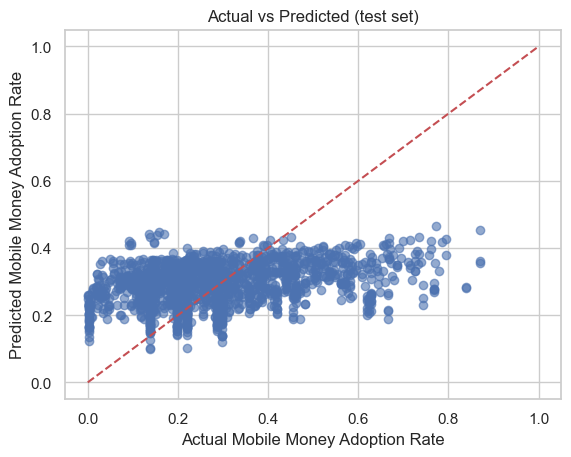

In [12]:
# Plot actual vs predicted
plt.Figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([0,1], [0,1], 'r--')
plt.title("Actual vs Predicted (test set)")
plt.xlabel("Actual Mobile Money Adoption Rate")
plt.ylabel("Predicted Mobile Money Adoption Rate")
plt.show()

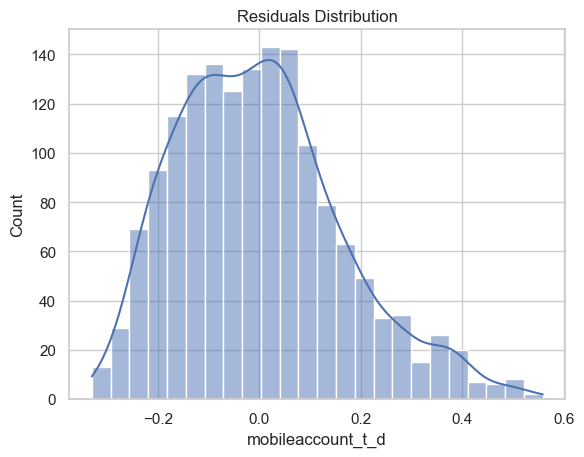

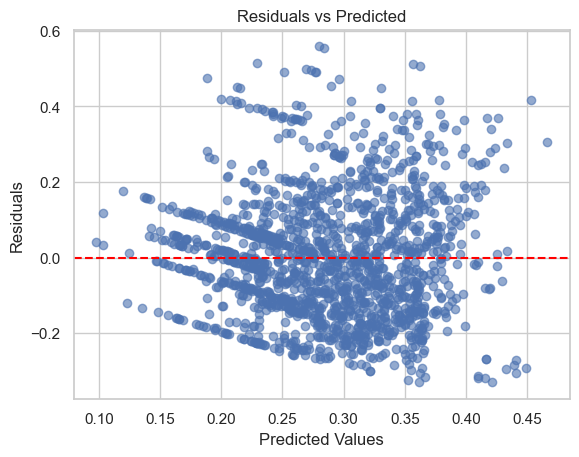


--- Variance Inflation Factor (VIF) ---
                                              feature       VIF
5                           regionwb24_hi_High income       inf
10                         incomegroupwb24_Low income       inf
11                incomegroupwb24_Lower middle income       inf
12                incomegroupwb24_Upper middle income       inf
9   regionwb24_hi_Sub-Saharan Africa (excluding hi...  4.501570
4   regionwb24_hi_Europe & Central Asia (excluding...  3.124621
6   regionwb24_hi_Latin America & Caribbean (exclu...  2.871177
2                                         account_t_d  2.427007
7   regionwb24_hi_Middle East & North Africa (excl...  2.009245
8    regionwb24_hi_South Asia (excluding high income)  1.645748
1                                           pop_adult  1.235095
0                                                year  1.224690
3                                            internet  1.205898
13                                              const  0.000000

c:\Users\shari\Downloads\projects_personal_files\Python\MobileMoney-Adoption-Analysis\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\shari\Downloads\projects_personal_files\Python\MobileMoney-Adoption-Analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [13]:
# Diagnostics - residuals & VIF

# Residuals
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

# Residuals vs predicted plot (scatter plot)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

# Variance Inflation Factor (VIF) to check multicollinearity

# --- 1. Prepare a temporary DataFrame for VIF calculation ---

# Create a copy of X_train features to avoid modifying the original
x_vif = X_train.copy()

# Ensure all data is numeric (float) for VIF calculation
x_vif = x_vif.astype(float)

# VIF requires an intercept (constant) term, so we add a constant column of 1s
x_vif['const'] = 1

# --- 2. Calculate VIF for each feature using a loop ---

# Create an empty DataFrame to store VIF results
vif_data = pd.DataFrame()

# Store the feature names in the DataFrame
vif_data['feature'] = x_vif.columns

# Calculate VIF for each feature
# We iterate over each column index (i) in x_vif from 0 to the number of columns
vif_data['VIF'] = [variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])]

# --- 3. Format & display the VIF results ---

# Sort VIF values in descending order for better readability
vif_data = vif_data.sort_values(by='VIF', ascending=False)

# Display the VIF results
print("\n--- Variance Inflation Factor (VIF) ---")
print(vif_data)


##  Model Diagnosis: Multicollinearity (Dummy Variable Trap)
The Variance Inflation Factor (VIF) analysis revealed a severe issue: **Perfect Multicollinearity** (VIF=inf) among several categorical features, including `regionwb24_hi_High income` and the three`incomegroupwb24` categories.

This indicates we fell into the Dummy Variable Trap, where all categories of a single variable were retained after One-Hot Encoding. This creates a linear dependency with the intercept term, making the model coefficients unstable and mathematically unreliable.

VIF=inf is caused by **Dummy Variable Trap:** Sum of all binary categories Intercept.

## Corrective Action
To resolve this, we must remove one redundant category from each set of encoded features. This is equivalent to setting a "reference category" for the model.

**Step:** Drop one column from the incomegroupwb24 set and the redundant regionwb24_hi_High income column from both X_train and X_test before re-running the model diagnostics and training.


--- VIF After Removing Highly Correlated Features ---
                                              feature       VIF
11                                              const  4.088472
10                incomegroupwb24_Upper middle income  2.802520
4   regionwb24_hi_Europe & Central Asia (excluding...  2.453882
5   regionwb24_hi_Latin America & Caribbean (exclu...  2.344225
8   regionwb24_hi_Sub-Saharan Africa (excluding hi...  2.216135
2                                         account_t_d  2.030179
9                 incomegroupwb24_Lower middle income  1.886823
6   regionwb24_hi_Middle East & North Africa (excl...  1.658532
7    regionwb24_hi_South Asia (excluding high income)  1.376211
3                                            internet  1.203108
0                                                year  1.197365
1                                           pop_adult  1.176002


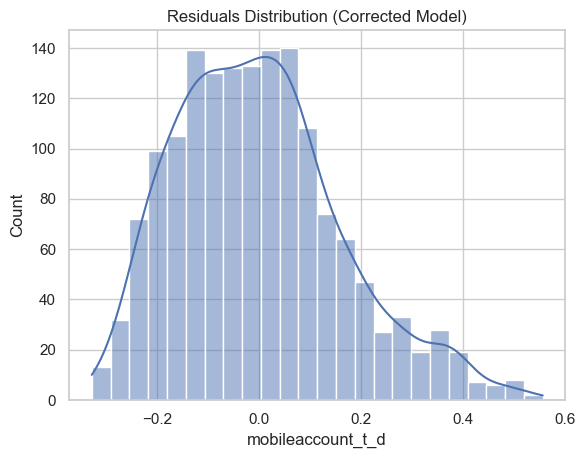

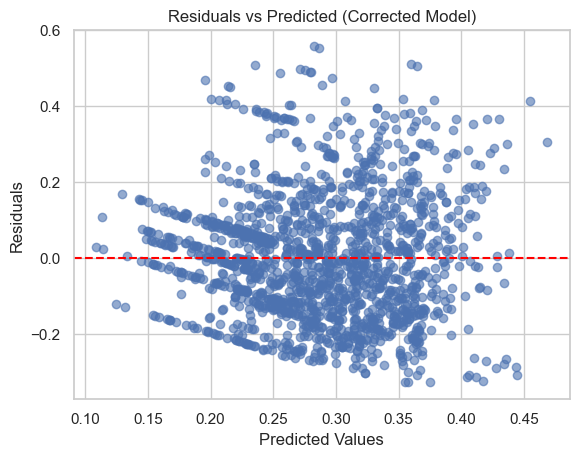


--- Corrected Model Evaluation ---
R-squared: 0.1182
Mean Squared Error (MSE): 0.0267
Root Mean Squared Error (RMSE): 0.1634


In [18]:
# Create new training/test sets without the highly correlated columns
X_train_corrected = X_train.drop(columns=['incomegroupwb24_Low income', 'regionwb24_hi_High income'])
X_test_corrected = X_test.drop(columns=['incomegroupwb24_Low income', 'regionwb24_hi_High income'])

# Re-run the VIF check using X_train_corrected 
x_vif_corrected = X_train_corrected.copy()
x_vif_corrected = x_vif_corrected.astype(float)

x_vif_corrected['const'] = 1

data_vif = pd.DataFrame()
data_vif['feature'] = x_vif_corrected.columns
data_vif['VIF'] = [variance_inflation_factor(x_vif_corrected.values, i) for i in range(x_vif_corrected.shape[1])]
data_vif = data_vif.sort_values(by='VIF', ascending=False)
print("\n--- VIF After Removing Highly Correlated Features ---")
print(data_vif)

# Retrain the model with corrected features
model_corrected = LinearRegression()
model_corrected.fit(X_train_corrected, y_train)
y_pred_corrected = model_corrected.predict(X_test_corrected)

# Residuals
residuals_corrected = y_test - y_pred_corrected
sns.histplot(residuals_corrected, kde=True)
plt.title("Residuals Distribution (Corrected Model)")
plt.show()

# Residuals vs predicted plot (scatter plot)
plt.scatter(y_pred_corrected, residuals_corrected, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted (Corrected Model)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

# Evaluate the corrected model performance
r2_corrected = r2_score(y_test, y_pred_corrected)
mse_corrected = mean_squared_error(y_test, y_pred_corrected)
rmse_corrected = np.sqrt(mse_corrected) 

# Print evaluation metrics for corrected model
print("\n--- Corrected Model Evaluation ---")
print(f"R-squared: {r2_corrected:.4f}")
print(f"Mean Squared Error (MSE): {mse_corrected:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_corrected:.4f}")



# Linear Regression Model Analysis: Diagnosis & Correction
The initial Linear Regression model was subjected to rigorous diagnostics to assess its stability and fit.

## Phase 1: Initial Diagnosis (Identifying Flaws)
| Diagnostic Tool | Observation | Conclusion |
| :--- | :---: | :--- |
| **VIF** | Several features displayed VIF=inf | **Severe multicollinearity (Dummy Variable Trap).** Coefficients were unstable and unreliable. |
| **Residuals plot** | Non-random "bow" pattern; Heteroscedasticity. | **Core Assumption of Linearity Violated.** Model is structurally inadequate. |
| **Actual vs. Predicted** | Predictions clustered horizontally (collapsed to the mean). | **Poor Predictive Power** |

## Phase 2: Corrective Action & Re-Evaluation

| Corrected Metric/Plot | Result | Conclusion|
| :--- | :---: | :--- |
| **Corrected VIF** | All scores $\text{VIF} < 3$ | **Model is stable.** The new coefficients are now reliable for statistical interpretation. |
|**Corrected R-squared** | $0.1182$ | **Predictive power remains poor.** Fixing the VIF did not improve the $R^2$. |
| **Corrected Residuals Plot** | Non-linear patterns and Heteroscedasticity persist. | **Linearity Assumption remains Violated.** A straight-line model is unsuitable for this data. |

## Conclusion and Next Step

The corrected Linear Regression model is **structurally sound** but **predictively insufficient** and **statistically invalid** due to the fundamentally non-linear relationship in the data.

We proceed to the final statistical step—extracting $P$-values from the OLS summary—to identify the statistically significant drivers before transitioning to a more powerful **Non-Linear Model** for improved predictive accuracy.


In [20]:
# Run OLS regression for detailed summary
X_train_corrected_float = X_train_corrected.astype(float)
X_train_sm = sm.add_constant(X_train_corrected_float)  # Add constant term for intercept
ols_model = sm.OLS(y_train, X_train_sm).fit()

print("\n--- OLS Statistical Summary (Final Corrected Model) ---")
print(ols_model.summary())


--- OLS Statistical Summary (Final Corrected Model) ---
                            OLS Regression Results                            
Dep. Variable:      mobileaccount_t_d   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     83.48
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          7.38e-177
Time:                        11:55:21   Log-Likelihood:                 2491.8
No. Observations:                6304   AIC:                            -4960.
Df Residuals:                    6292   BIC:                            -4879.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------

# Statistical Inference: Final OLS Regression Results

The OLS model was re-run using the corrected, stable feature set ($\text{X\_train\_corrected}$) to draw reliable statistical inferences about the drivers of Mobile Money Adoption.

## Key Performance Metrics

| Metric |	Value |	Interpretation |
| :--- | :---: | :--- |
| **R-squared ($\text{R}^2$)** | $0.127$ | The model explains $12.7\%$ of the variability in Mobile Money Adoption. This confirms the **poor predictive fit.** |
| **Prob (F-statistic)** | $7.38\text{e-}177$ (or $0.000$) | The model, as a whole, is **statistically significant** and better than a model with no predictors. |

## Feature Coefficients and Significance ($\alpha=0.05$)

The table below details the coefficient, $P$-value, and significance of each predictor, establishing their relationship with the Mobile Money Adoption Rate ($\text{mobileaccount\_t\_d}$).

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:left">Feature</th>
      <th style="text-align:center">Coefficient (coef)</th>
      <th style="text-align:center">P>|t|</th>
      <th style="text-align:center">Significance</th>
      <th style="text-align:left">Impact on Adoption</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><b>year</b></td>
      <td style="text-align:center">+0.0414</td>
      <td style="text-align:center">0.000</td>
      <td style="text-align:center"><b>Highly Significant</b></td>
      <td><b>Strong Positive.</b> Adoption increases by ≈ 4.14 percentage points per year.</td>
    </tr>
    <tr>
      <td><b>account_t_d</b></td>
      <td style="text-align:center">+0.0396</td>
      <td style="text-align:center">0.000</td>
      <td style="text-align:center"><b>Highly Significant</b></td>
      <td><b>Positive.</b> Higher traditional banking access is correlated with higher Mobile Money Adoption.</td>
    </tr>
    <tr>
      <td><b>internet</b></td>
      <td style="text-align:center">+0.0146</td>
      <td style="text-align:center">0.000</td>
      <td style="text-align:center"><b>Highly Significant</b></td>
      <td><b>Positive.</b> Higher internet penetration drives adoption.</td>
    </tr>
    <tr>
      <td><b>regionwb24_hi_Sub-Saharan Africa...</b></td>
      <td style="text-align:center">+0.0970</td>
      <td style="text-align:center">0.000</td>
      <td style="text-align:center"><b>Highly Significant</b></td>
      <td><b>Strongest Positive.</b> Adoption is highest in this region compared to the baseline (High Income regions).</td>
    </tr>
    <tr>
      <td><b>incomegroupwb24_Lower middle income</b></td>
      <td style="text-align:center">+0.0333</td>
      <td style="text-align:center">0.000</td>
      <td style="text-align:center"><b>Highly Significant</b></td>
      <td><b>Positive.</b> Higher adoption than the low-income baseline group.</td>
    </tr>
    <tr>
      <td><b>regionwb24_hi_Europe...</b></td>
      <td style="text-align:center">+0.0356</td>
      <td style="text-align:center">0.000</td>
      <td style="text-align:center"><b>Highly Significant</b></td>
      <td><b>Positive.</b> High adoption relative to the baseline.</td>
    </tr>
    <tr>
      <td><b>pop_adult</b></td>
      <td style="text-align:center">-0.0027</td>
      <td style="text-align:center">0.234</td>
      <td style="text-align:center">Not Significant</td>
      <td>Adult population size does not reliably influence the rate.</td>
    </tr>
    <tr>
      <td><b>regionwb24_hi_South Asia...</b></td>
      <td style="text-align:center">+0.0148</td>
      <td style="text-align:center">0.204</td>
      <td style="text-align:center">Not Significant</td>
      <td>Not a significant predictor in this model.</td>
    </tr>
  </tbody>
</table>




## Conclusion on Statistical Drivers

Despite the model's poor predictive power, the OLS analysis provides reliable insight into the statistical drivers:

1. **Strongest Drivers: Sub-Saharan Africa region** ($\text{coef}=+0.0970$), the **passage of time** ($\text{year}$), and **traditional banking access** ($\text{account\_t\_d}$) are the most robust positive predictors of Mobile Money Adoption.
2. Implications: The results suggest that Mobile Money often complements traditional banking and digital connectivity, rather than simply substituting them.

## Next Step

Given the poor $\text{R}^2$ ($0.127$) and the confirmed violation of model assumptions, the Linear Regression analysis is complete. The project must now transition to a **non-linear regression model** (such as Random Forest or XGBoost) to achieve a high-performing predictive model.
